In [30]:
!apt-get install -y portaudio19-dev
!pip install pyaudio


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram, find_peaks
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

# Set up beautiful plotting style for notebook
plt.rcParams['figure.figsize'] = [14, 8]
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

#  PART 1: SINUSOIDS

##   What is a Sinusoid?

A sinusoid is a mathematical curve that describes a smooth periodic oscillation:

**x(t) = A × sin(2πft + φ)**

Where:
- **A** = Amplitude (loudness/volume)
- **f** = Frequency (pitch in Hz)
- **φ** = Phase (horizontal shift)
- **t** = Time

**Key Insight:** Any sound, no matter how complex, is just a sum of sinusoids!


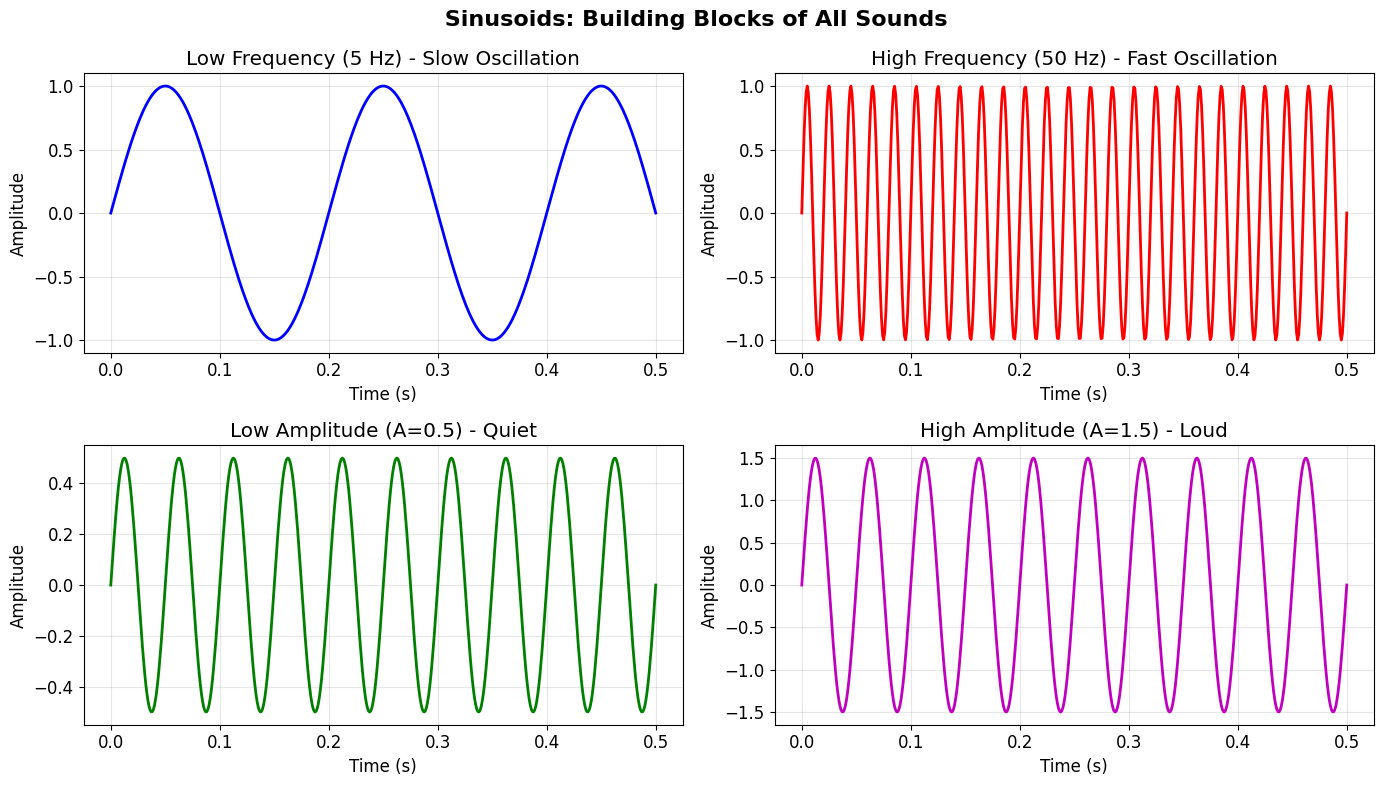

In [44]:








def create_sinusoid(freq, amplitude=1, phase=0, duration=1, fs=8000):
    """Create a sinusoid: x(t) = A * sin(2πft + φ)"""
    t = np.linspace(0, duration, int(fs * duration))
    signal = amplitude * np.sin(2 * np.pi * freq * t + phase)
    return t, signal

# Create and visualize different sinusoids
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Different frequencies
t, low_freq = create_sinusoid(5, duration=0.5, fs=1000)
axes[0,0].plot(t, low_freq, 'b-', linewidth=2)
axes[0,0].set_title('Low Frequency (5 Hz) - Slow Oscillation')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Amplitude')

t, high_freq = create_sinusoid(50, duration=0.5, fs=1000)
axes[0,1].plot(t, high_freq, 'r-', linewidth=2)
axes[0,1].set_title('High Frequency (50 Hz) - Fast Oscillation')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Amplitude')

# Different amplitudes
t, low_amp = create_sinusoid(20, amplitude=0.5, duration=0.5, fs=1000)
axes[1,0].plot(t, low_amp, 'g-', linewidth=2)
axes[1,0].set_title('Low Amplitude (A=0.5) - Quiet')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Amplitude')

t, high_amp = create_sinusoid(20, amplitude=1.5, duration=0.5, fs=1000)
axes[1,1].plot(t, high_amp, 'm-', linewidth=2)
axes[1,1].set_title('High Amplitude (A=1.5) - Loud')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('Amplitude')

plt.suptitle(' Sinusoids: Building Blocks of All Sounds', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()





###  Observation:

- **Frequency** controls how many oscillations per second (pitch)

- **Amplitude** controls the strength (loudness)

- **Phase** controls where the wave starts

##  Combining Sinusoids to Create Complex Sounds

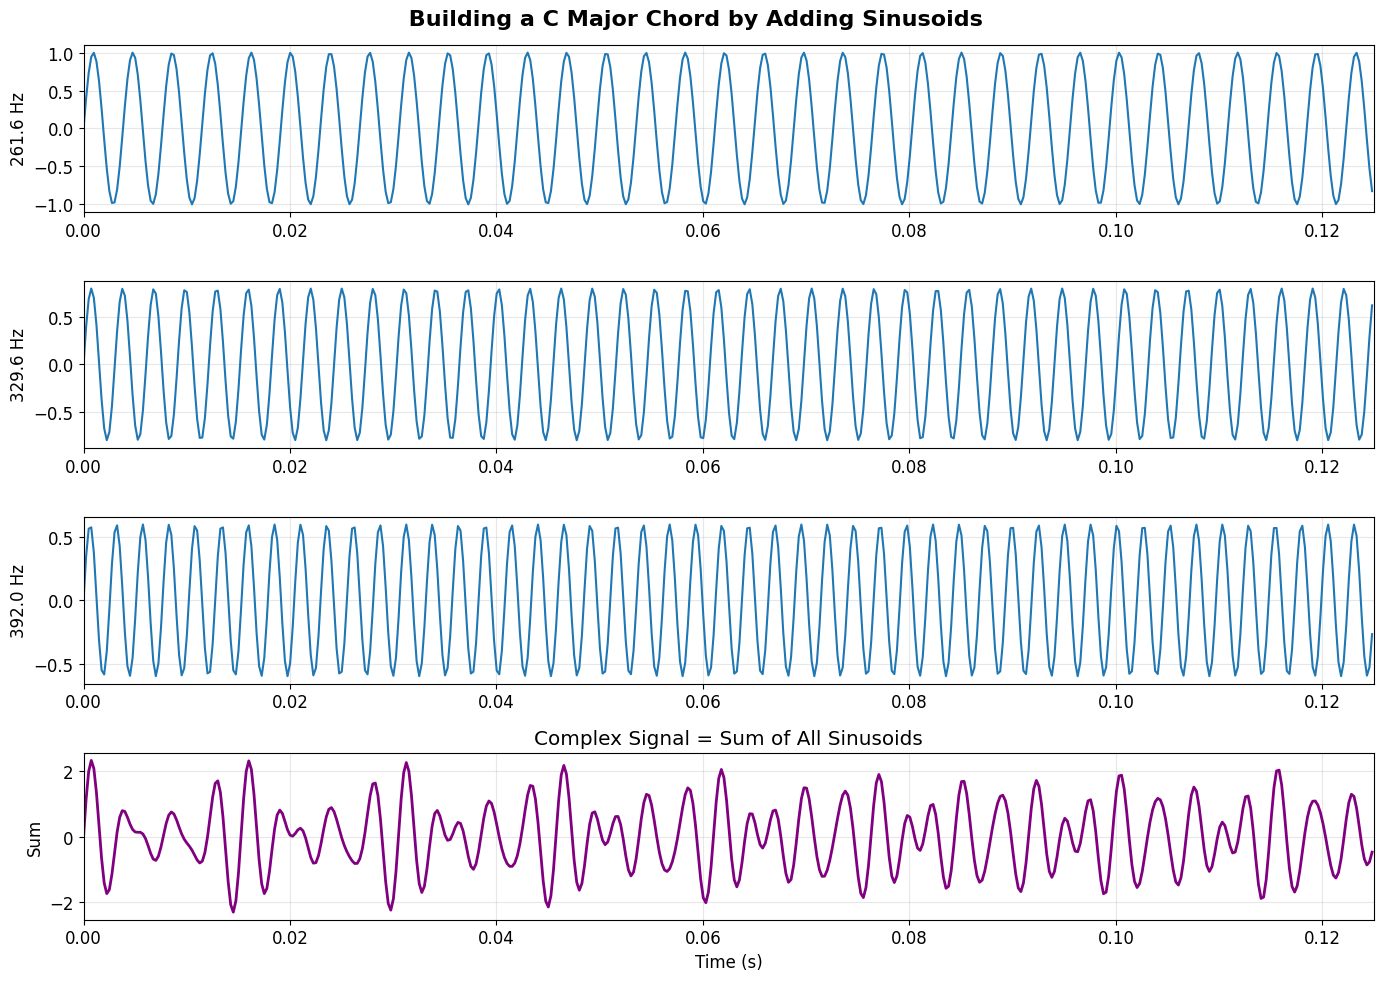

In [47]:


"""Any complex sound is created by adding multiple sinusoids together!"""

def combine_sinusoids(frequencies, amplitudes, duration=1, fs=8000):
    """Combine multiple sinusoids into one complex signal"""
    t = np.linspace(0, duration, int(fs * duration))
    signal = np.zeros_like(t)

    for freq, amp in zip(frequencies, amplitudes):
        signal += amp * np.sin(2 * np.pi * freq * t)

    return t, signal

# Create a chord: C major (C4=261.63Hz, E4=329.63Hz, G4=392.00Hz)
chord_freqs = [261.63, 329.63, 392.00]
chord_amps = [1, 0.8, 0.6]

t, chord_signal = combine_sinusoids(chord_freqs, chord_amps, duration=0.5, fs=4000)

# Plot individual components and their sum
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Individual components
for i, (freq, amp) in enumerate(zip(chord_freqs, chord_amps)):
    _, component = create_sinusoid(freq, amp, duration=0.5, fs=4000)
    axes[i].plot(t[:500], component[:500], linewidth=1.5)
    axes[i].set_ylabel(f'{freq:.1f} Hz')
    axes[i].set_xlim(0, 0.125)
    axes[i].grid(True, alpha=0.3)

# Sum of all components
axes[3].plot(t[:500], chord_signal[:500], 'purple', linewidth=2)
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Sum')
axes[3].set_title('Complex Signal = Sum of All Sinusoids')
axes[3].set_xlim(0, 0.125)

plt.suptitle(' Building a C Major Chord by Adding Sinusoids', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# PART 2: DFT IMPLEMENTATION FROM SCRATCH

**Discrete Fourier Transform (DFT) Formula:**

X[k] = Σ_{n=0}^{N-1} x[n] · e^{-j·2π·k·n/N}

Where:
- x[n] = input signal in time domain
- X[k] = frequency domain representation
- N = number of samples
- k = frequency bin index
- j = imaginary unit (√-1)

**What DFT does:** It checks "how much" of each frequency exists in the signal.


 Reconstruction Error: 1.57e-14
 DFT matches NumPy FFT: True


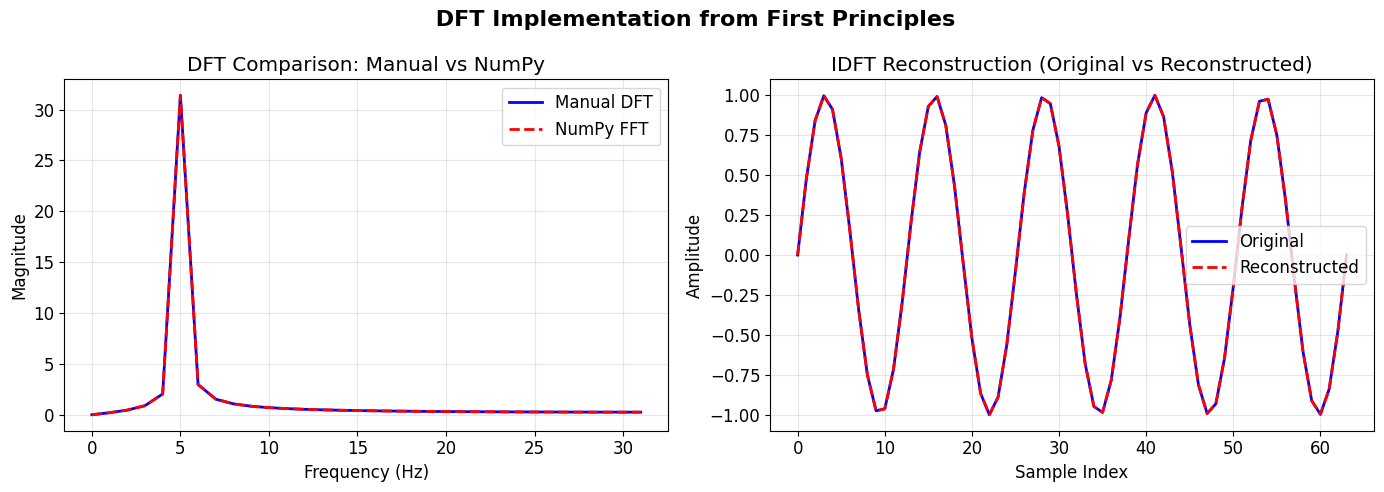

In [50]:





def dft_from_scratch(x):
    """
    Manual implementation of DFT
    X[k] = Σ x[n] * exp(-j*2π*k*n/N)
    """
    N = len(x)
    X = np.zeros(N, dtype=complex)

    # For each frequency bin
    for k in range(N):
        # Sum over all time samples
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)

    return X

def idft_from_scratch(X):
    """
    Manual implementation of IDFT
    x[n] = (1/N) Σ X[k] * exp(j*2π*k*n/N)
    """
    N = len(X)
    x = np.zeros(N, dtype=complex)

    # For each time sample
    for n in range(N):
        # Sum over all frequency bins
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)

    return x / N

# Test with a simple signal
test_signal = np.sin(2 * np.pi * 5 * np.linspace(0, 1, 64))  # 5 Hz sine wave

# Compute DFT manually and with numpy
dft_manual = dft_from_scratch(test_signal)
dft_numpy = np.fft.fft(test_signal)

# Compare results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freqs = np.fft.fftfreq(len(test_signal), 1/64)

axes[0].plot(freqs[:32], np.abs(dft_manual[:32]), 'b-', label='Manual DFT', linewidth=2)
axes[0].plot(freqs[:32], np.abs(dft_numpy[:32]), 'r--', label='NumPy FFT', linewidth=2)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('DFT Comparison: Manual vs NumPy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction test
reconstructed = idft_from_scratch(dft_manual)
axes[1].plot(test_signal[:100], 'b-', label='Original', linewidth=2)
axes[1].plot(reconstructed[:100].real, 'r--', label='Reconstructed', linewidth=2)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('IDFT Reconstruction (Original vs Reconstructed)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

error = np.max(np.abs(test_signal - reconstructed.real))
print(f" Reconstruction Error: {error:.2e}")
print(f" DFT matches NumPy FFT: {np.allclose(dft_manual, dft_numpy)}")

plt.suptitle(' DFT Implementation from First Principles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


#  PART 3: FREQUENCY BINS & RESOLUTION

##  Understanding Frequency Bins

DFT splits the frequency spectrum into discrete "bins":

**f_k = k × (Fs/N)**

Where:
- f_k = frequency of bin k
- Fs = sampling rate
- N = number of samples
- k = bin index (0 to N-1)

**Key Concept:** The longer your signal (more samples), the better frequency resolution!

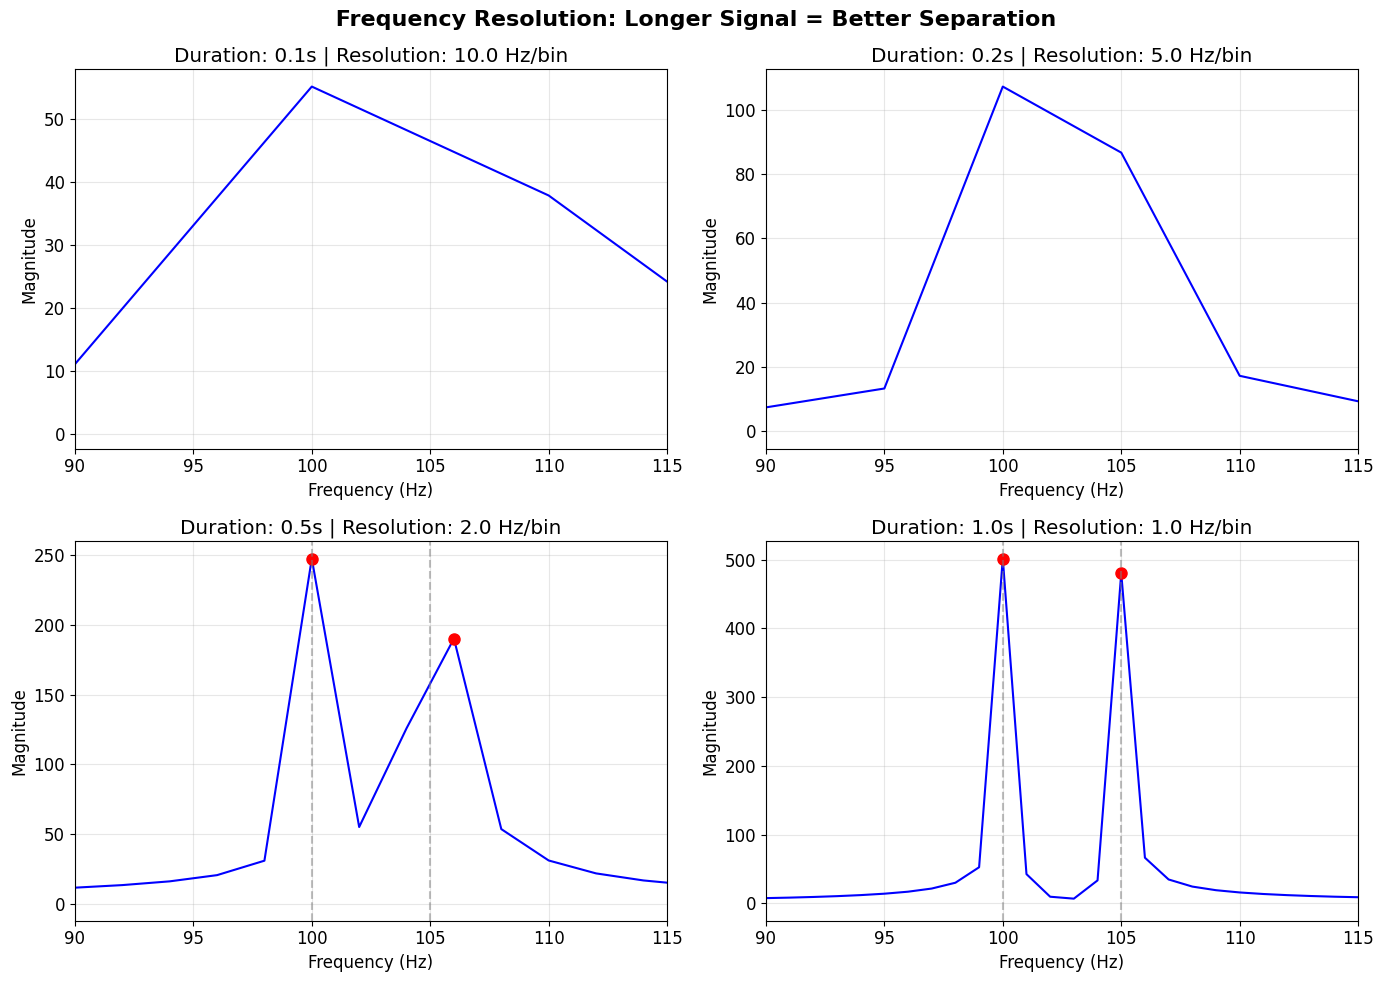


 Key Insight:
  • With 0.1s signal → Resolution = 10 Hz/bin → Can't separate 100Hz & 105Hz
  • With 1.0s signal → Resolution = 1 Hz/bin → Clearly sees both frequencies!


In [55]:

def demonstrate_frequency_resolution(fs=1000):
    """Show how signal duration affects frequency resolution"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    durations = [0.1, 0.2, 0.5, 1.0]

    for idx, duration in enumerate(durations):
        # Create signal with two close frequencies
        t = np.linspace(0, duration, int(fs * duration))
        signal = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 105 * t)

        # Compute DFT
        X = np.fft.fft(signal)
        freqs = np.fft.fftfreq(len(t), 1/fs)

        # Plot
        ax = axes[idx // 2, idx % 2]
        ax.plot(freqs[:len(freqs)//2], np.abs(X[:len(X)//2]), 'b-', linewidth=1.5)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Magnitude')
        ax.set_title(f'Duration: {duration}s | Resolution: {1/duration:.1f} Hz/bin')
        ax.set_xlim(90, 115)
        ax.grid(True, alpha=0.3)

        # Find peaks
        peaks, _ = find_peaks(np.abs(X[:len(X)//2]), height=np.max(np.abs(X[:len(X)//2]))*0.5)
        if len(peaks) >= 2:
            peak_freqs = freqs[peaks[:2]]
            ax.plot(peak_freqs, np.abs(X[peaks[:2]]), 'ro', markersize=8)
            ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(105, color='gray', linestyle='--', alpha=0.5)

    plt.suptitle(' Frequency Resolution: Longer Signal = Better Separation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n Key Insight:")
    print(f"  • With 0.1s signal → Resolution = 10 Hz/bin → Can't separate 100Hz & 105Hz")
    print(f"  • With 1.0s signal → Resolution = 1 Hz/bin → Clearly sees both frequencies!")
demonstrate_frequency_resolution()

#  PART 4: REAL AUDIO ANALYSIS

In [71]:
# Load your audio file
audio_file = "/content/Recording.wav"

try:
    fs, audio = wavfile.read(audio_file)
    print(f" Successfully loaded: {audio_file}")
    print(f" Audio Information:")
    print(f"   • Sampling Rate: {fs} Hz")
    print(f"   • Duration: {len(audio)/fs:.2f} seconds")
    print(f"   • Total Samples: {len(audio):,}")

    # Convert to mono if stereo
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)
        print(f"   • Channels: Stereo → Mono")
    else:
        print(f"   • Channels: Mono")

    # Normalize
    audio = audio / np.max(np.abs(audio))
    print(f"   • Normalized: [-1, 1] range")

except Exception as e:
    print(f" Error loading file: {e}")
    print("   Please ensure the file exists at /content/Recording.wav")
    # Create a synthetic test signal if file not found
    fs = 8000
    t = np.linspace(0, 3, int(3 * fs))
    audio = np.sin(2 * np.pi * 440 * t) * np.exp(-2 * t)  # Decaying 440 Hz tone
    print("\n  Using synthetic test signal for demonstration")

# Play audio (if in notebook)
#try:
   # ipd.display(ipd.Audio(audio, rate=fs))
#except:
    #print(" Audio ready for playback")

 Successfully loaded: /content/Recording.wav
 Audio Information:
   • Sampling Rate: 48000 Hz
   • Duration: 41.69 seconds
   • Total Samples: 2,001,120
   • Channels: Stereo → Mono
   • Normalized: [-1, 1] range


##  Time Domain Visualization

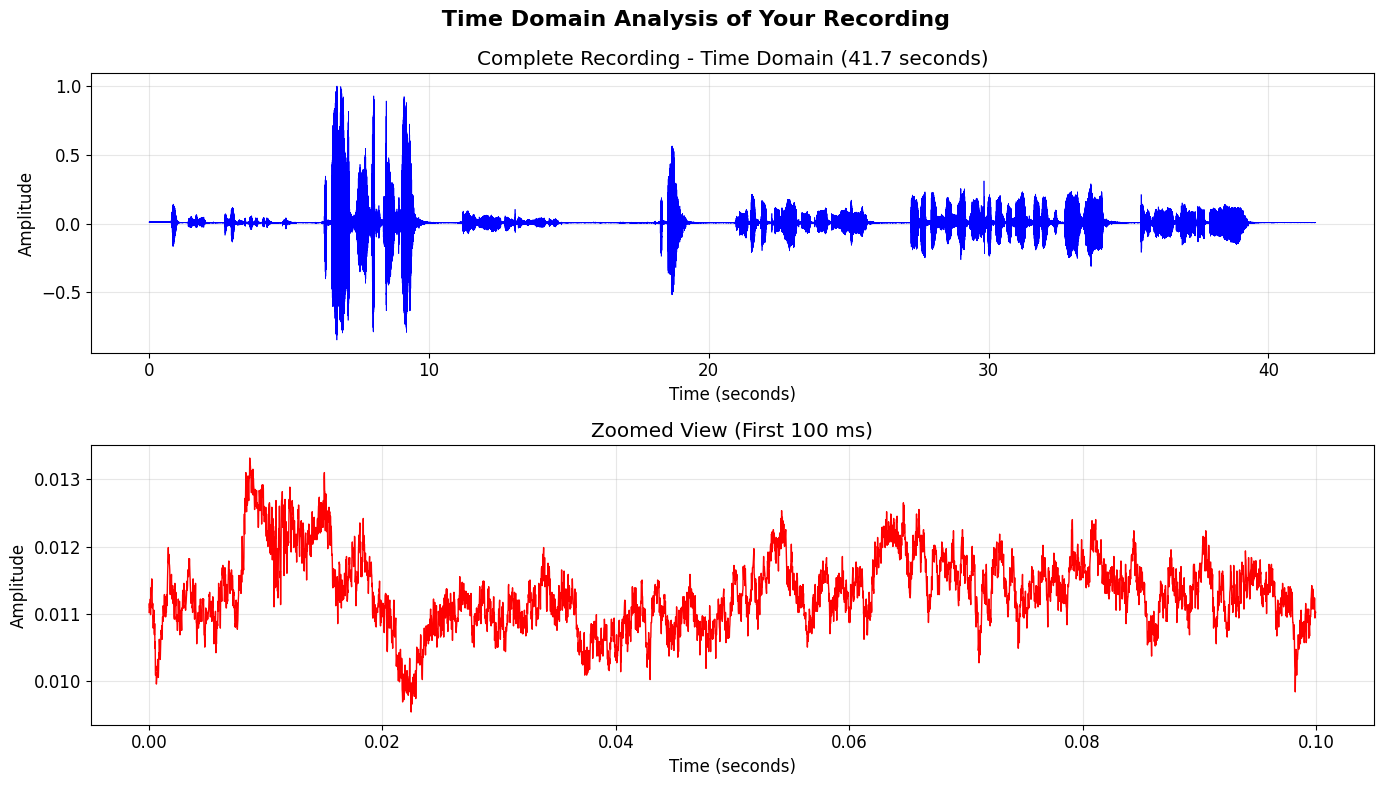

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full signal
time = np.arange(len(audio)) / fs
axes[0].plot(time, audio, 'b-', linewidth=0.5)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Complete Recording - Time Domain ({len(audio)/fs:.1f} seconds)')
axes[0].grid(True, alpha=0.3)

# Zoomed view (first 0.1 seconds)
zoom_duration = min(0.1, len(audio)/fs)
zoom_samples = int(zoom_duration * fs)
axes[1].plot(time[:zoom_samples], audio[:zoom_samples], 'r-', linewidth=1)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Zoomed View (First {zoom_duration*1000:.0f} ms)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(' Time Domain Analysis of Your Recording', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Frequency Domain: What Frequencies Are Present

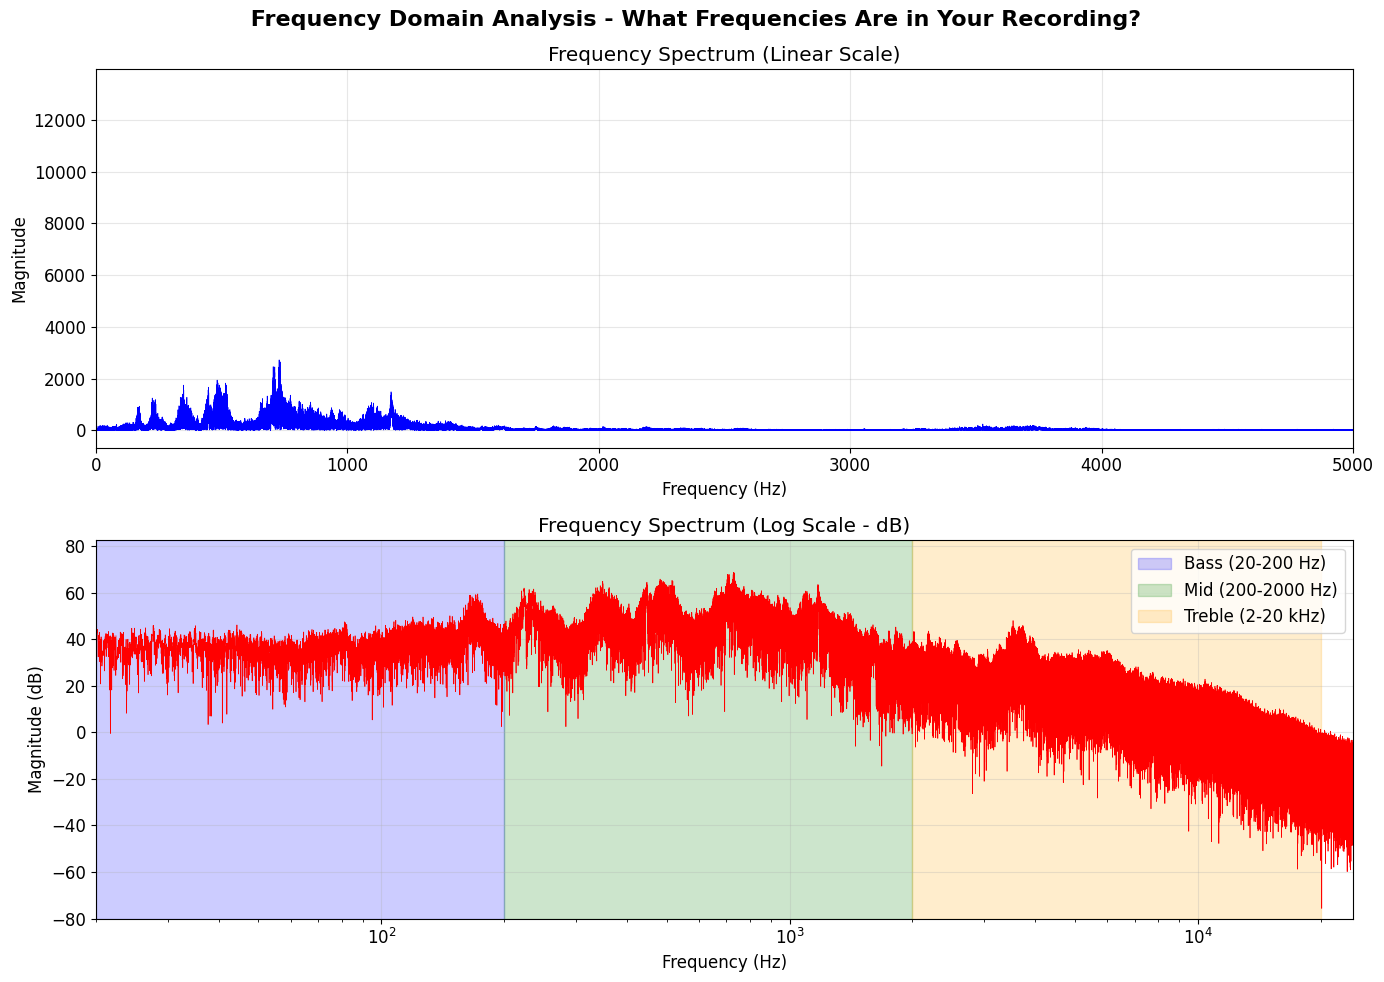

In [69]:
X = np.fft.fft(audio)
frequencies = np.fft.fftfreq(len(audio), 1/fs)

# Take positive frequencies only
positive_idx = frequencies >= 0
frequencies_pos = frequencies[positive_idx]
magnitude_pos = np.abs(X[positive_idx])

# Convert to dB scale for better visualization
magnitude_db = 20 * np.log10(magnitude_pos + 1e-10)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Linear scale (showing strong components)
axes[0].plot(frequencies_pos, magnitude_pos, 'b-', linewidth=0.5)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('Frequency Spectrum (Linear Scale)')
axes[0].set_xlim(0, min(5000, fs/2))
axes[0].grid(True, alpha=0.3)

# Log scale (better for seeing all frequencies)
axes[1].semilogx(frequencies_pos[1:], magnitude_db[1:], 'r-', linewidth=0.5)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('Frequency Spectrum (Log Scale - dB)')
axes[1].set_xlim(20, fs/2)
axes[1].set_ylim(-80, np.max(magnitude_db))
axes[1].grid(True, alpha=0.3)

# Add frequency region annotations
axes[1].axvspan(20, 200, alpha=0.2, color='blue', label='Bass (20-200 Hz)')
axes[1].axvspan(200, 2000, alpha=0.2, color='green', label='Mid (200-2000 Hz)')
axes[1].axvspan(2000, 20000, alpha=0.2, color='orange', label='Treble (2-20 kHz)')
axes[1].legend(loc='upper right')

plt.suptitle(' Frequency Domain Analysis - What Frequencies Are in Your Recording?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##  Finding Dominant Frequencies


 TOP 15 DOMINANT FREQUENCIES:
Rank   Frequency (Hz)  Magnitude    Musical Note
------------------------------------------------------------
1      728.4           2727.37      A4          
2      732.3           2649.45      A4          
3      729.3           2520.53      A4          
4      704.8           2465.63      G#4         
5      710.9           2454.64      G#4         
6      727.7           2445.31      A4          
7      706.1           2441.80      G#4         
8      731.5           2289.39      A4          
9      733.2           2159.01      A4          
10     709.6           2139.95      G#4         
11     730.7           2138.19      A4          
12     728.8           2132.64      A4          
13     728.0           2115.44      A4          
14     729.7           2115.16      A4          
15     730.2           2090.42      A4          


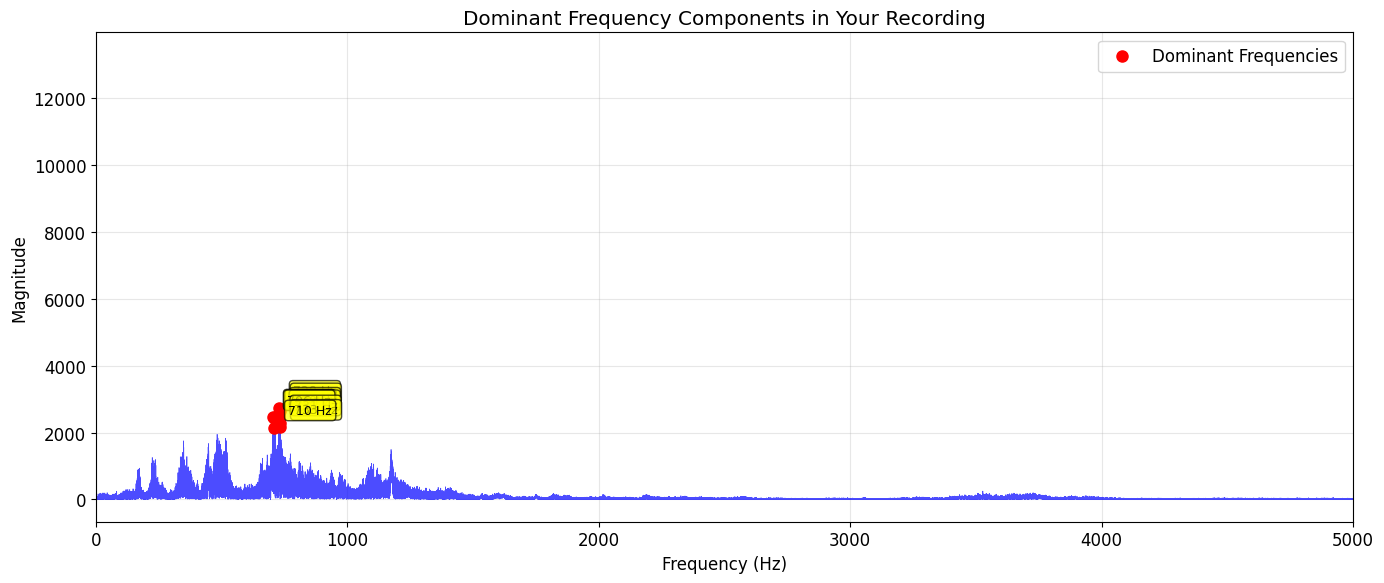

In [67]:
# Find peaks in the spectrum
peaks, properties = find_peaks(magnitude_pos,
                               height=np.max(magnitude_pos) * 0.1,
                               distance=10)  # Minimum distance between peaks

# Sort peaks by magnitude
peak_magnitudes = magnitude_pos[peaks]
sorted_indices = np.argsort(peak_magnitudes)[::-1]
top_peaks = peaks[sorted_indices[:15]]  # Top 15 peaks

print("\n TOP 15 DOMINANT FREQUENCIES:")
print("="*60)
print(f"{'Rank':<6} {'Frequency (Hz)':<15} {'Magnitude':<12} {'Musical Note':<12}")
print("-"*60)

def freq_to_note(freq):
    """Convert frequency to nearest musical note"""
    if freq < 20:
        return "Sub-bass"
    if freq > 20000:
        return "Ultrasonic"

    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    # A4 = 440 Hz
    semitone = 12 * np.log2(freq / 440)
    note_index = int(round(semitone)) % 12
    octave = 4 + int(round(semitone)) // 12

    return f"{notes[note_index]}{octave}"

for rank, peak_idx in enumerate(top_peaks[:15], 1):
    freq = frequencies_pos[peak_idx]
    mag = magnitude_pos[peak_idx]
    note = freq_to_note(freq)
    print(f"{rank:<6} {freq:<15.1f} {mag:<12.2f} {note:<12}")

# Visualize peaks
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(frequencies_pos, magnitude_pos, 'b-', linewidth=0.5, alpha=0.7)
ax.plot(frequencies_pos[top_peaks[:10]], magnitude_pos[top_peaks[:10]], 'ro', markersize=8, label='Dominant Frequencies')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title('Dominant Frequency Components in Your Recording')
ax.set_xlim(0, min(5000, fs/2))
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate peaks
for peak_idx in top_peaks[:10]:
    freq = frequencies_pos[peak_idx]
    mag = magnitude_pos[peak_idx]
    ax.annotate(f'{freq:.0f} Hz',
                xy=(freq, mag),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

## Spectrogram - Time-Frequency Analysis

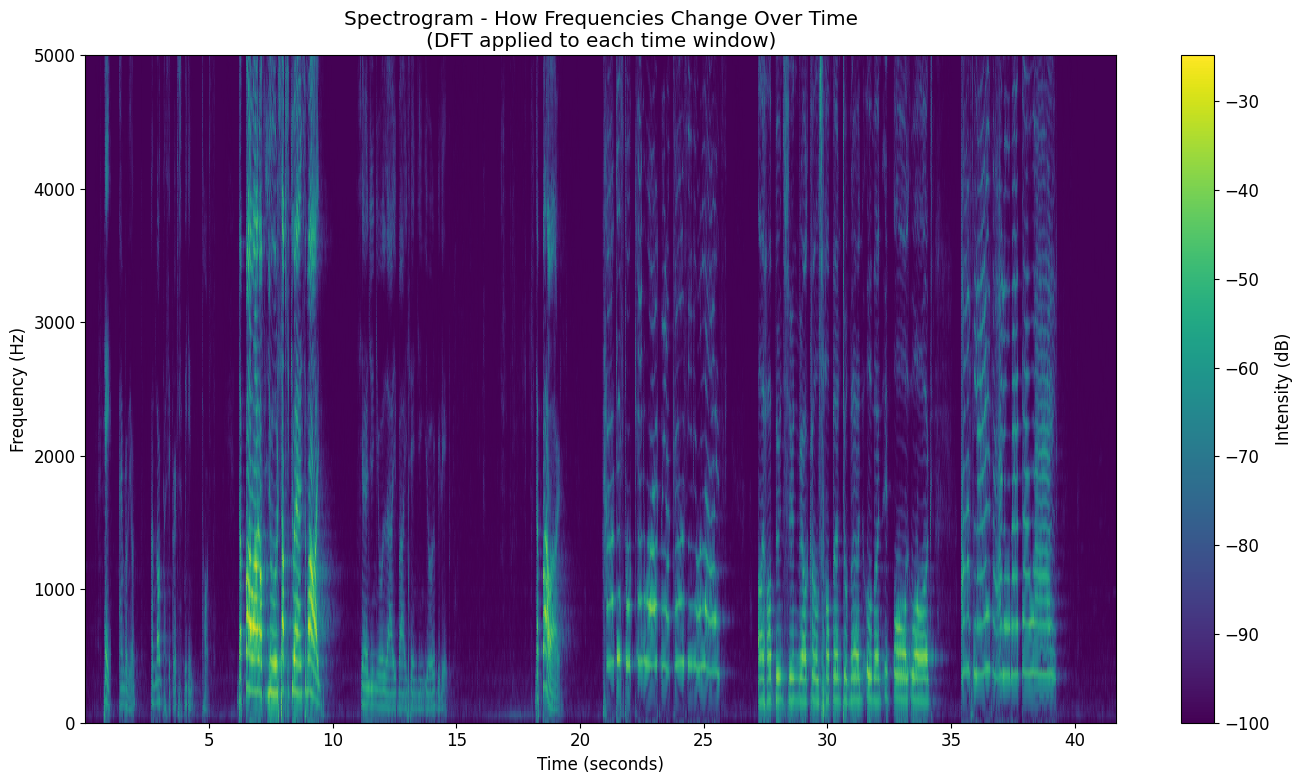


 What the spectrogram shows:
  • X-axis: Time progression
  • Y-axis: Frequency content
  • Color: Energy/amplitude at that time-frequency point
  • Dark regions: Silence or low energy
  • Bright regions: Strong frequency components


In [65]:


# Compute spectrogram
f, t, Sxx = spectrogram(audio, fs, nperseg=1024, noverlap=512)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot spectrogram
im = ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10),
                   shading='gouraud', cmap='viridis')
plt.colorbar(im, ax=ax, label='Intensity (dB)')

ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_title('Spectrogram - How Frequencies Change Over Time\n(DFT applied to each time window)')
ax.set_ylim(0, min(5000, fs/2))
ax.grid(False)

plt.tight_layout()
plt.show()

print("\n What the spectrogram shows:")
print("  • X-axis: Time progression")
print("  • Y-axis: Frequency content")
print("  • Color: Energy/amplitude at that time-frequency point")
print("  • Dark regions: Silence or low energy")
print("  • Bright regions: Strong frequency components")

## Signal Reconstruction from Frequencie

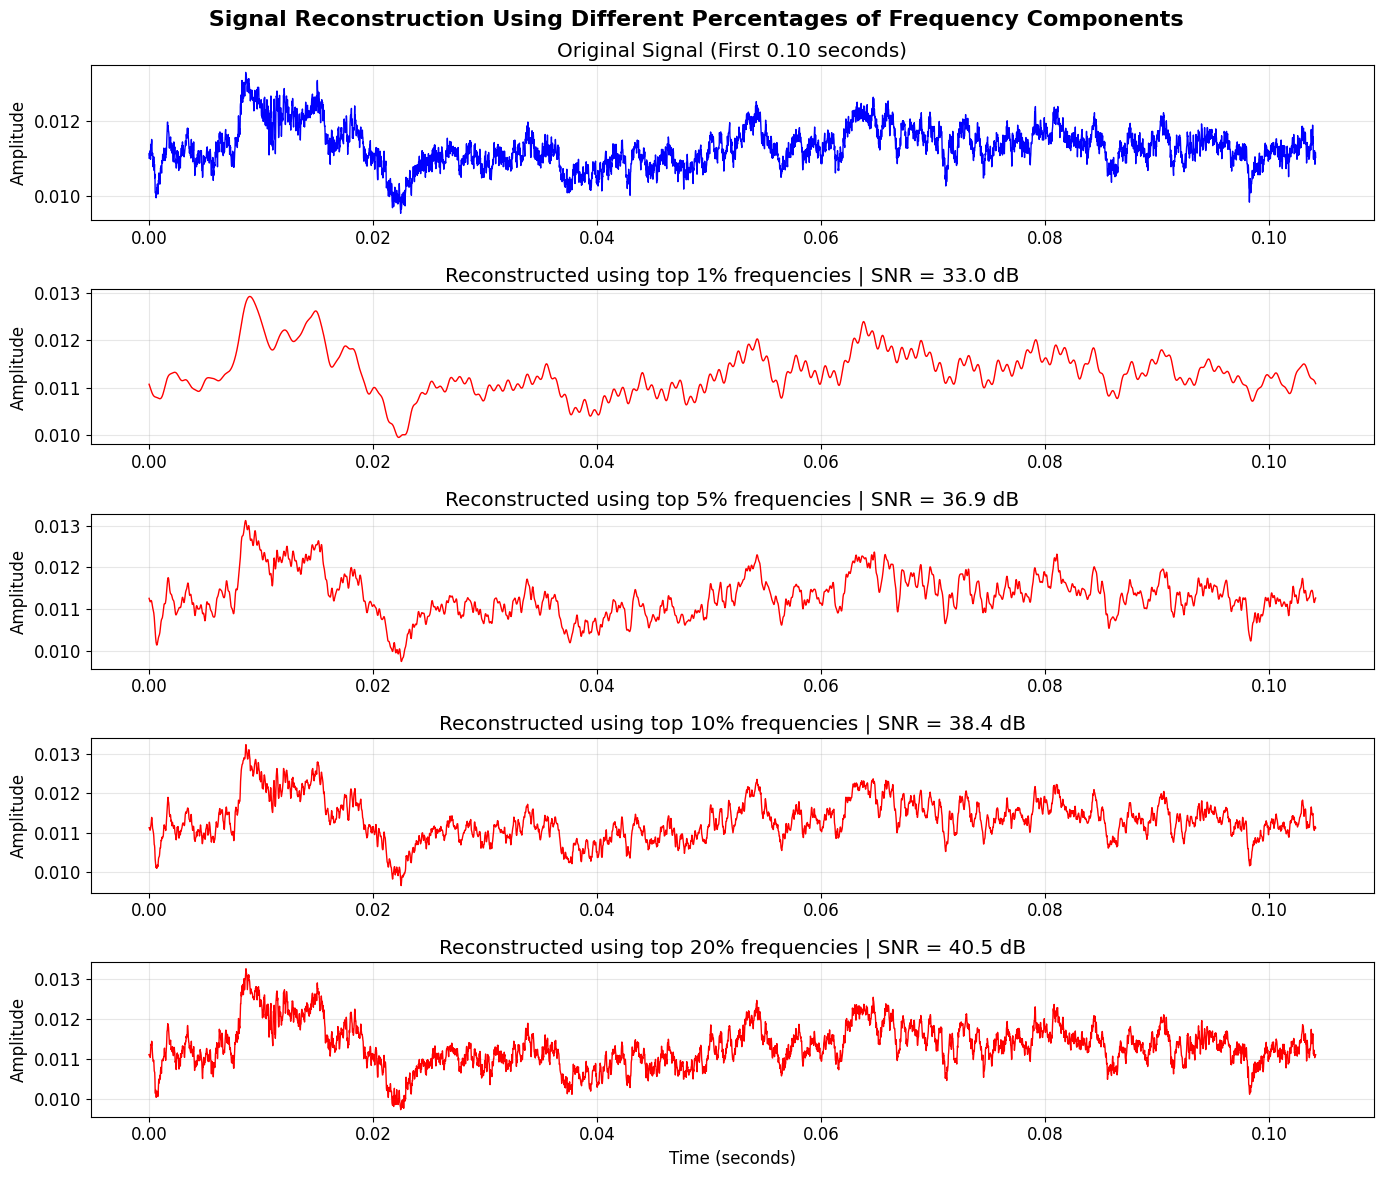


 Key Insight:
  • Even with only 1-5% of frequencies, we can capture the essence of the signal!
  • This is the basis of audio compression (MP3, AAC, etc.)
  • DFT reveals which frequencies are most important for perception


In [66]:



def reconstruct_from_frequencies(signal, fs, keep_percentage=10):
    """Reconstruct signal using only top k% frequencies"""

    # Compute DFT
    X = np.fft.fft(signal)

    # Keep only top frequencies
    magnitude = np.abs(X)
    threshold = np.percentile(magnitude, 100 - keep_percentage)
    X_filtered = X.copy()
    X_filtered[magnitude < threshold] = 0

    # Reconstruct
    reconstructed = np.fft.ifft(X_filtered).real

    return reconstructed

# Take a segment for reconstruction
segment_length = min(5000, len(audio))
test_segment = audio[:segment_length]

# Reconstruct with different percentages
percentages = [1, 5, 10, 20]

fig, axes = plt.subplots(len(percentages) + 1, 1, figsize=(14, 12))

# Original
time_seg = np.arange(len(test_segment)) / fs
axes[0].plot(time_seg, test_segment, 'b-', linewidth=1)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Original Signal (First {segment_length/fs:.2f} seconds)')
axes[0].grid(True, alpha=0.3)

# Reconstructions
for i, percent in enumerate(percentages, 1):
    reconstructed = reconstruct_from_frequencies(test_segment, fs, percent)
    axes[i].plot(time_seg, reconstructed, 'r-', linewidth=1)
    axes[i].set_ylabel('Amplitude')

    # Calculate reconstruction quality
    mse = np.mean((test_segment - reconstructed)**2)
    snr = 10 * np.log10(np.mean(test_segment**2) / (mse + 1e-10))
    axes[i].set_title(f'Reconstructed using top {percent}% frequencies | SNR = {snr:.1f} dB')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle(' Signal Reconstruction Using Different Percentages of Frequency Components', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Key Insight:")
print("  • Even with only 1-5% of frequencies, we can capture the essence of the signal!")
print("  • This is the basis of audio compression (MP3, AAC, etc.)")
print("  • DFT reveals which frequencies are most important for perception")

##  Harmonic Analysis

Fundamental Frequency: 114.0 Hz (C#2)

Harmonic   Expected (Hz)   Detected (Hz)   Magnitude    Ratio   
1          114.0           114.0           1.20         1.00    
2          228.0           228.0           0.37         0.31    
3          342.0           342.0           0.30         0.25    
4          456.0           456.0           0.07         0.06    
5          570.0           570.0           0.21         0.18    
6          684.0           684.0           0.12         0.10    
7          798.0           798.0           0.11         0.09    
8          912.0           912.0           0.06         0.05    
9          1026.0          1026.0          0.06         0.05    
10         1140.0          1140.0          0.08         0.06    


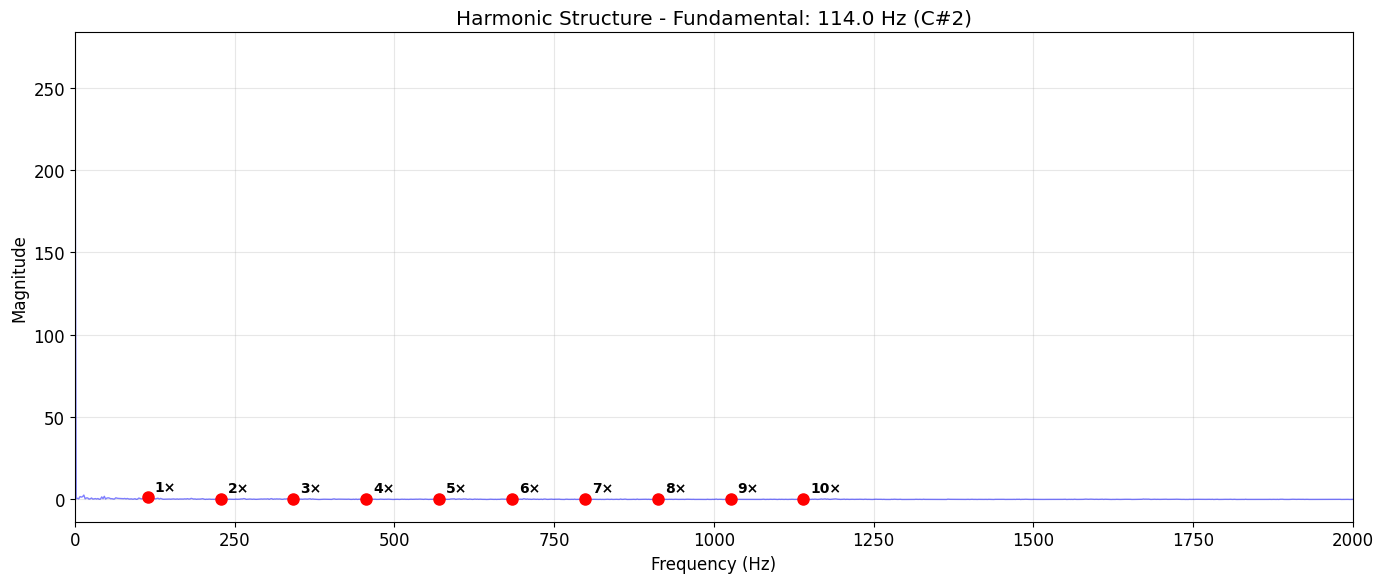

In [68]:
def analyze_harmonics(signal, fs, fundamental_freq=None):
    """Analyze harmonic structure of a signal"""

    # Compute DFT
    X = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    magnitude = np.abs(X)

    # Only positive frequencies
    pos_idx = freqs >= 0
    freqs_pos = freqs[pos_idx]
    mag_pos = magnitude[pos_idx]

    # Auto-detect fundamental if not provided
    if fundamental_freq is None:
        # Look for strongest peak between 50-500 Hz (typical speech/music range)
        voice_range = (freqs_pos >= 50) & (freqs_pos <= 500)
        if np.any(voice_range):
            fundamental_freq = freqs_pos[voice_range][np.argmax(mag_pos[voice_range])]
        else:
            fundamental_freq = freqs_pos[np.argmax(mag_pos)]


    print(f"Fundamental Frequency: {fundamental_freq:.1f} Hz ({freq_to_note(fundamental_freq)})")
    print(f"\n{'Harmonic':<10} {'Expected (Hz)':<15} {'Detected (Hz)':<15} {'Magnitude':<12} {'Ratio':<8}")


    harmonics = []
    for n in range(1, 11):
        harmonic_freq = fundamental_freq * n

        # Find closest frequency bin
        idx = np.argmin(np.abs(freqs_pos - harmonic_freq))
        detected_freq = freqs_pos[idx]
        mag = mag_pos[idx]

        if mag > 0:
            ratio = mag / mag_pos[np.argmin(np.abs(freqs_pos - fundamental_freq))]
            harmonics.append((n, harmonic_freq, detected_freq, mag, ratio))
            print(f"{n:<10} {harmonic_freq:<15.1f} {detected_freq:<15.1f} {mag:<12.2f} {ratio:<8.2f}")

    # Visualize harmonics
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot full spectrum
    ax.plot(freqs_pos[:2000], mag_pos[:2000], 'b-', linewidth=1, alpha=0.5)

    # Highlight harmonics
    for n, exp_freq, det_freq, mag, ratio in harmonics:
        if det_freq < 2000:  # Limit to visible range
            ax.plot(det_freq, mag, 'ro', markersize=8)
            ax.annotate(f'{n}×',
                       xy=(det_freq, mag),
                       xytext=(5, 5),
                       textcoords='offset points',
                       fontsize=10,
                       fontweight='bold')

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'Harmonic Structure - Fundamental: {fundamental_freq:.1f} Hz ({freq_to_note(fundamental_freq)})')
    ax.set_xlim(0, min(2000, fs/2))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return harmonics

# Analyze harmonics of the audio
if len(audio) > 0:
    # Use a segment with clear pitch
    segment_duration = min(0.5, len(audio)/fs)
    segment = audio[:int(segment_duration * fs)]
    harmonics = analyze_harmonics(segment, fs)
